In [65]:
import pandas as pd

file_path = 'dane/cleaned_data.csv'
df_modeling = pd.read_csv(file_path)
df_modeling.head()

,Perfume_ID,Name,Brand,Gender,Rating Value,Rating Count,Clean_Accords,Description,Semantic_Text,url,Main Accords
0,70706,9am,Afnan,for women,3.73,174.0,"citrus, musky, woody, aromatic, warm spicy, la...",9am by Afnan is a fragrance for women. Top not...,Perfume: 9am by Afnan. 9am by Afnan is a fragr...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['citrus', 'musky', 'woody', 'aromatic', 'warm..."
1,78611,9am Dive,Afnan,for women and men,4.29,842.0,"fruity, woody, green, warm spicy, aromatic, ci...",9am Dive by Afnan is a Aromatic Aquatic fragra...,Perfume: 9am Dive by Afnan. 9am Dive by Afnan ...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'woody', 'green', 'warm spicy', 'ar..."
2,78541,9am pour Femme,Afnan,for women,4.00,68.0,"fruity, musky, amber, citrus, powdery, sweet, ...",9am pour Femme by Afnan is a Amber fragrance f...,Perfume: 9am pour Femme by Afnan. 9am pour Fem...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'musky', 'amber', 'citrus', 'powder..."
3,78544,9pm pour Femme,Afnan,for women,3.49,63.0,"woody, aromatic, rose, fruity, powdery, violet...",9pm pour Femme by Afnan is a Amber Floral frag...,Perfume: 9pm pour Femme by Afnan. 9pm pour Fem...,https://www.fragrantica.com/perfume/Afnan/9pm-...,"['woody', 'aromatic', 'rose', 'fruity', 'powde..."
4,36596,Black Oudh,Al Haramain Perfumes,for women and men,4.12,113.0,"woody, powdery, musky, amber, patchouli, vanil...",Black Oudh by Al Haramain Perfumes is a Amber ...,Perfume: Black Oudh by Al Haramain Perfumes. B...,https://www.fragrantica.com/perfume/Al-Haramai...,"['woody', 'powdery', 'musky', 'amber', 'patcho..."


In [66]:
sample_texts = df_modeling.sample(10, random_state=123)

print("--- STRUKTURA TEKSTU SEMANTYCZNEGO DO ANALIZY ---")
for index, row in sample_texts.iterrows():
    print(f"\nPERFUMY: {row['Name']} (Marka: {row['Brand']})")
    print("SEMANTIC TEXT:")
    print(row['Semantic_Text'])
    print("-" * 70)

--- STRUKTURA TEKSTU SEMANTYCZNEGO DO ANALIZY ---

PERFUMY: Patchouli Wood (Marka: Ajmal)
SEMANTIC TEXT:
Perfume: Patchouli Wood by Ajmal. Patchouli Wood by Ajmal is a Woody Spicy fragrance for women and men.Patchouli Woodwas launched in 2016. Top notes are Woodsy Notes and Spices; middle note is Floral Notes; base notes are Agarwood (Oud), Patchouli and Woody Notes. Main accords: woody, oud, patchouli, warm spicy, floral, earthy, balsamic.
----------------------------------------------------------------------

PERFUMY: Amethyst Exquise (Marka: Lalique)
SEMANTIC TEXT:
Perfume: Amethyst Exquise by Lalique. Amethyst Exquise by Lalique is a Floral Fruity fragrance for women.Amethyst Exquisewas launched in 2017. Top notes are Blackberry, Black Currant, Raspberry and Heliotrope; middle notes are Orchid and Bulgarian Rose; base notes are Vanilla, Sandalwood, Benzoin and Gardenia. Main accords: fruity, sweet, floral, powdery, vanilla.
----------------------------------------------------------

In [67]:
import pandas as pd
import re

def extract_pure_scent_profile(text):
    if not isinstance(text, str):
        return ""
        
    accords_match = re.search(r'(Main accords:.*)', text, re.IGNORECASE)
    accords = accords_match.group(1).strip() if accords_match else ""
    
    notes_pattern = r'((?:Top notes|Middle notes|Base notes|Fragrance notes).*?)(?=\.\s*Main accords|\.\s*$)'
    notes_match = re.search(notes_pattern, text, re.IGNORECASE)
    notes = notes_match.group(1).strip() if notes_match else ""
    
    clean_text = f"{accords}. {notes}".strip(' .').replace('..', '.')
    
    return clean_text

sample_texts = [
    "Perfume: Patchouli Wood by Ajmal. Patchouli Wood by Ajmal is a Woody Spicy fragrance for women and men.Patchouli Woodwas launched in 2016. Top notes are Woodsy Notes and Spices; middle note is Floral Notes; base notes are Agarwood (Oud), Patchouli and Woody Notes. Main accords: woody, oud, patchouli, warm spicy, floral, earthy, balsamic.",
    "Perfume: Amethyst Exquise by Lalique. Amethyst Exquise by Lalique is a Floral Fruity fragrance for women.Amethyst Exquisewas launched in 2017. Top notes are Blackberry, Black Currant, Raspberry and Heliotrope; middle notes are Orchid and Bulgarian Rose; base notes are Vanilla, Sandalwood, Benzoin and Gardenia. Main accords: fruity, sweet, floral, powdery, vanilla.",
    "Perfume: Frutas Tropicais by Natura. Frutas Tropicais by Natura is a Aromatic Fruity fragrance for women. This is a new fragrance.Frutas Tropicaiswas launched in 2022. The nose behind this fragrance is Verônica Kato. Top notes are Coconut Water, Pineapple, Pitanga, Passionfruit, Pear, Apple, Orange, Bergamot, Lemon, Grapefruit and Mint; middle notes are Freesia, Jasmine and Lily-of-the-Valley; base notes are Maltol, Amber, Musk, Sandalwood and Cedar. Main accords: fruity, sweet, fresh, tropical, floral, white floral."
]

print("WYNIKI EKSTRAKCJI NLP")
for i, text in enumerate(sample_texts, 1):
    print(f"\nPróbka {i}:")
    print(extract_pure_scent_profile(text))

WYNIKI EKSTRAKCJI NLP

Próbka 1:
Main accords: woody, oud, patchouli, warm spicy, floral, earthy, balsamic. Top notes are Woodsy Notes and Spices; middle note is Floral Notes; base notes are Agarwood (Oud), Patchouli and Woody Notes

Próbka 2:
Main accords: fruity, sweet, floral, powdery, vanilla. Top notes are Blackberry, Black Currant, Raspberry and Heliotrope; middle notes are Orchid and Bulgarian Rose; base notes are Vanilla, Sandalwood, Benzoin and Gardenia

Próbka 3:
Main accords: fruity, sweet, fresh, tropical, floral, white floral. Top notes are Coconut Water, Pineapple, Pitanga, Passionfruit, Pear, Apple, Orange, Bergamot, Lemon, Grapefruit and Mint; middle notes are Freesia, Jasmine and Lily-of-the-Valley; base notes are Maltol, Amber, Musk, Sandalwood and Cedar


In [68]:
df_modeling['Semantic_Text'] = df_modeling['Semantic_Text'].apply(extract_pure_scent_profile)
for i, text in enumerate(df_modeling['Semantic_Text'].head(10)):
    print(f"\nRekord {i}:")
    print(text)
    print("-" * 80)


Rekord 0:
Main accords: citrus, musky, woody, aromatic, warm spicy, lavender, mossy, fruity, earthy, white floral. Top notes are Lemon, Mandarin Orange, Cardamom and Pink Pepper; middle notes are Lavender, Green Apple, Orange Blossom and Rose; base notes are Musk, Moss, Cedar and Patchouli
--------------------------------------------------------------------------------

Rekord 1:
Main accords: fruity, woody, green, warm spicy, aromatic, citrus, fresh, fresh spicy, soft spicy, amber. Top notes are Lemon, Mint, Black Currant and Pink Pepper; middle notes are Apple, Incense and Cedar; base notes are Ginger, Sandalwood, Patchouli and Jasmine
--------------------------------------------------------------------------------

Rekord 2:
Main accords: fruity, musky, amber, citrus, powdery, sweet, animalic, soft spicy. Top notes are Mandarin Orange, Grapefruit and Bergamot; middle notes are Raspberry and Black Currant; base notes are Musk, Amber and Orange
---------------------------------------

In [69]:
only_accords_df = df_modeling[~df_modeling['Semantic_Text'].str.contains('notes', case=False, na=False)]

total_records = len(df_modeling)
missing_notes_count = len(only_accords_df)
percentage = (missing_notes_count / total_records) * 100

print("--- ANALIZA BRAKUJĄCYCH NUT ZAPACHOWYCH ---")
print(f"Liczba perfum z samymi akordami (bez nut): {missing_notes_count}")
print(f"Stanowi to: {percentage:.2f}% całej bazy.")

--- ANALIZA BRAKUJĄCYCH NUT ZAPACHOWYCH ---
Liczba perfum z samymi akordami (bez nut): 5762
Stanowi to: 26.56% całej bazy.


In [70]:
import pandas as pd
import re

def create_pure_tag_profile(row):
    text = str(row['Semantic_Text'])
    gender = str(row['Gender']).strip().lower() if pd.notna(row['Gender']) else "unisex"
    
    text = re.sub(r'Main accords:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'(?:Top|Middle|Base|Fragrance) notes? (?:are|is)\s*', '', text, flags=re.IGNORECASE)
    
    text = re.sub(r'\s+and\s+', ',', text, flags=re.IGNORECASE)
    text = text.replace(';', ',').replace('.', ',')
    
    tags = [tag.strip().lower() for tag in text.split(',') if tag.strip()]
    
    unique_tags = list(dict.fromkeys(tags))
    
    final_profile = f"gender {gender}, " + ", ".join(unique_tags)
    
    return final_profile

print("Rozpoczynam generowanie ostatecznych, surowych profili zapachowych...")

df_modeling['Semantic_Text'] = df_modeling.apply(create_pure_tag_profile, axis=1)

for i, text in enumerate(df_modeling['Semantic_Text'].head(3)):
    print(f"\nRekord {i}: {text}")

Rozpoczynam generowanie ostatecznych, surowych profili zapachowych...

Rekord 0: gender for women, citrus, musky, woody, aromatic, warm spicy, lavender, mossy, fruity, earthy, white floral, lemon, mandarin orange, cardamom, pink pepper, green apple, orange blossom, rose, musk, moss, cedar, patchouli

Rekord 1: gender for women and men, fruity, woody, green, warm spicy, aromatic, citrus, fresh, fresh spicy, soft spicy, amber, lemon, mint, black currant, pink pepper, apple, incense, cedar, ginger, sandalwood, patchouli, jasmine

Rekord 2: gender for women, fruity, musky, amber, citrus, powdery, sweet, animalic, soft spicy, mandarin orange, grapefruit, bergamot, raspberry, black currant, musk, orange


In [71]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [72]:
texts = df_modeling['Semantic_Text'].tolist()

embeddings = model.encode(texts, show_progress_bar=True)
df_modeling['Embeddings'] = list(embeddings)

Batches:   0%|          | 0/678 [00:00<?, ?it/s]

1. Redukcja wymiarów (PCA z 384 do 2 osi X i Y)...


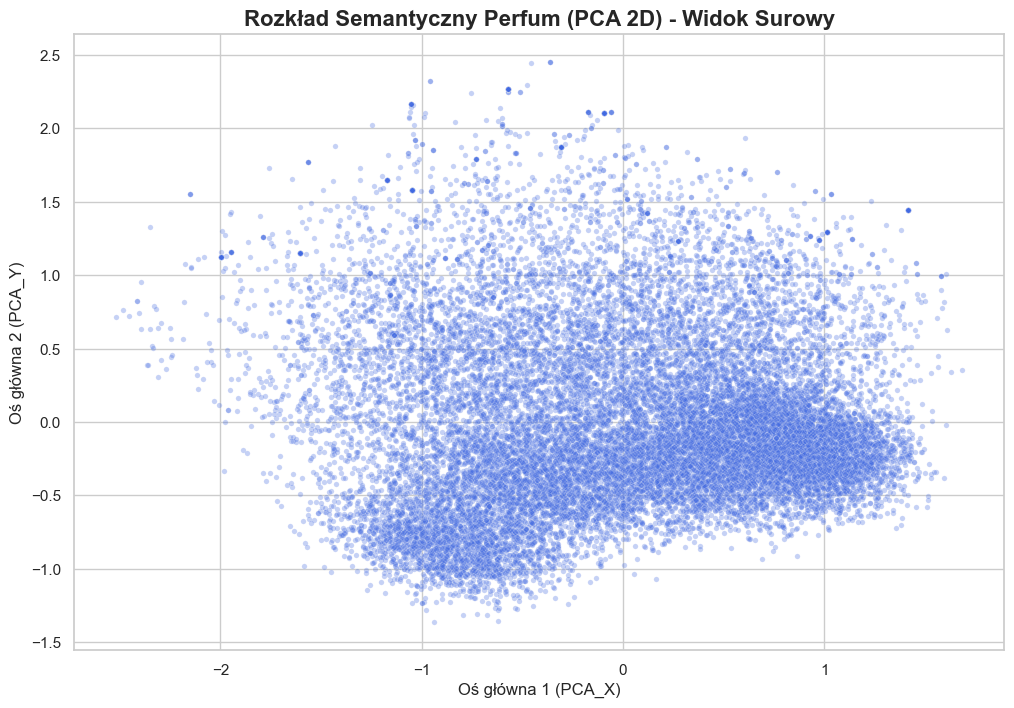

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

X_embeddings = np.array(df_modeling['Embeddings'].tolist())

print("1. Redukcja wymiarów (PCA z 384 do 2 osi X i Y)...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_embeddings)

df_modeling['PCA_X'] = X_pca[:, 0]
df_modeling['PCA_Y'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    x=df_modeling['PCA_X'], 
    y=df_modeling['PCA_Y'], 
    alpha=0.3, 
    s=15, 
    color='royalblue'
)

plt.title('Rozkład Semantyczny Perfum (PCA 2D) - Widok Surowy', fontsize=16, fontweight='bold')
plt.xlabel('Oś główna 1 (PCA_X)', fontsize=12)
plt.ylabel('Oś główna 2 (PCA_Y)', fontsize=12)
plt.show()

Dla K=2 -> Silhouette Score: 0.4237
Dla K=3 -> Silhouette Score: 0.4551
Dla K=4 -> Silhouette Score: 0.4301
Dla K=5 -> Silhouette Score: 0.3900
Dla K=6 -> Silhouette Score: 0.3405
Dla K=7 -> Silhouette Score: 0.3839
Dla K=8 -> Silhouette Score: 0.3542
Dla K=9 -> Silhouette Score: 0.3483
Dla K=10 -> Silhouette Score: 0.3503


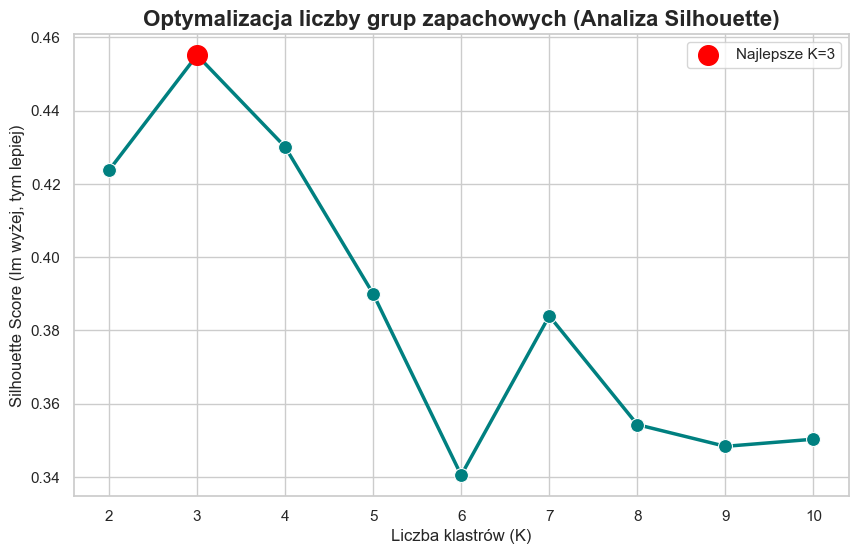


Matematycznie najlepszy podział to K=3 (Wynik: 0.4551)


In [74]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    
    cluster_labels = kmeans.fit_predict(df_modeling[['PCA_X', 'PCA_Y']])
    
    score = silhouette_score(df_modeling[['PCA_X', 'PCA_Y']], cluster_labels)
    
    silhouette_scores.append(score)
    print(f"Dla K={k} -> Silhouette Score: {score:.4f}")

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(x=k_values, y=silhouette_scores, marker='o', markersize=10, color='teal', linewidth=2.5)

best_k_index = silhouette_scores.index(max(silhouette_scores))
best_k = k_values[best_k_index]
best_score = silhouette_scores[best_k_index]
plt.scatter(best_k, best_score, color='red', s=200, zorder=5, label=f'Najlepsze K={best_k}')

plt.title('Optymalizacja liczby grup zapachowych (Analiza Silhouette)', fontsize=16, fontweight='bold')
plt.xlabel('Liczba klastrów (K)', fontsize=12)
plt.ylabel('Silhouette Score (Im wyżej, tym lepiej)', fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.show()

print(f"\nMatematycznie najlepszy podział to K={best_k} (Wynik: {best_score:.4f})")

Liczba klastrów (grup): 3
Wynik Silhouette Score: 0.4551


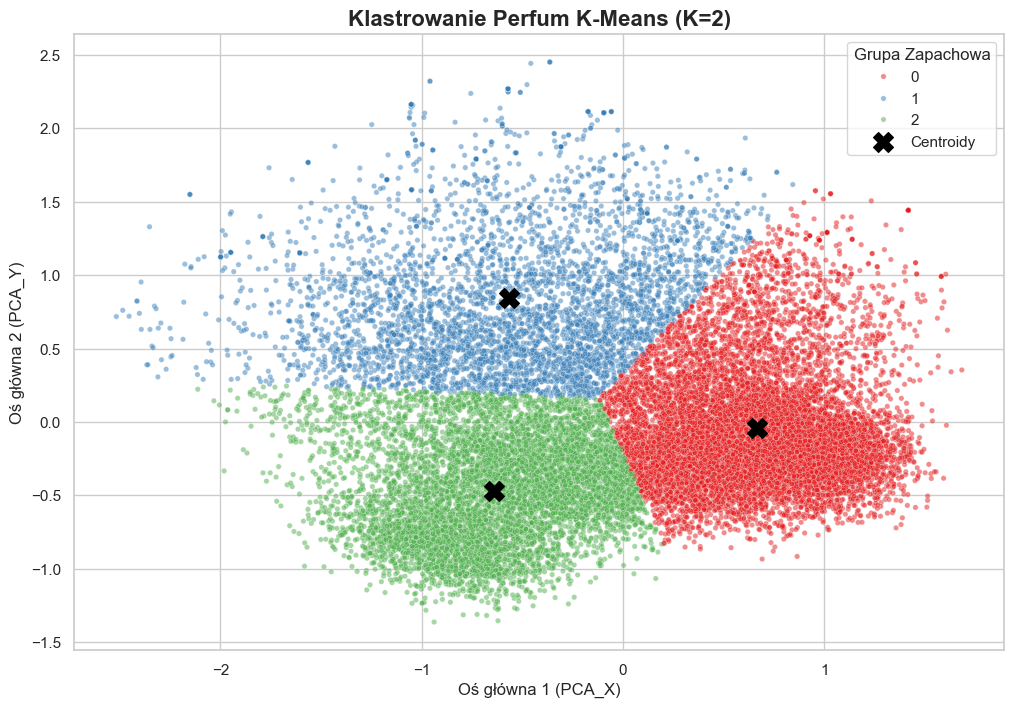

In [75]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

num_clusters = 2

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")

df_modeling['Cluster_ID'] = kmeans.fit_predict(df_modeling[['PCA_X', 'PCA_Y']])

sil_score = silhouette_score(df_modeling[['PCA_X', 'PCA_Y']], df_modeling['Cluster_ID'])

print(f"Liczba klastrów (grup): {best_k}")
print(f"Wynik Silhouette Score: {sil_score:.4f}")

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    x=df_modeling['PCA_X'], 
    y=df_modeling['PCA_Y'], 
    hue=df_modeling['Cluster_ID'], 
    palette='Set1', 
    alpha=0.5, 
    s=15
)

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Centroidy')

plt.title(f'Klastrowanie Perfum K-Means (K={num_clusters})', fontsize=16, fontweight='bold')
plt.xlabel('Oś główna 1 (PCA_X)', fontsize=12)
plt.ylabel('Oś główna 2 (PCA_Y)', fontsize=12)
plt.legend(title='Grupa Zapachowa')
plt.show()

Znaleziono 150 perfum Dior w bazie.


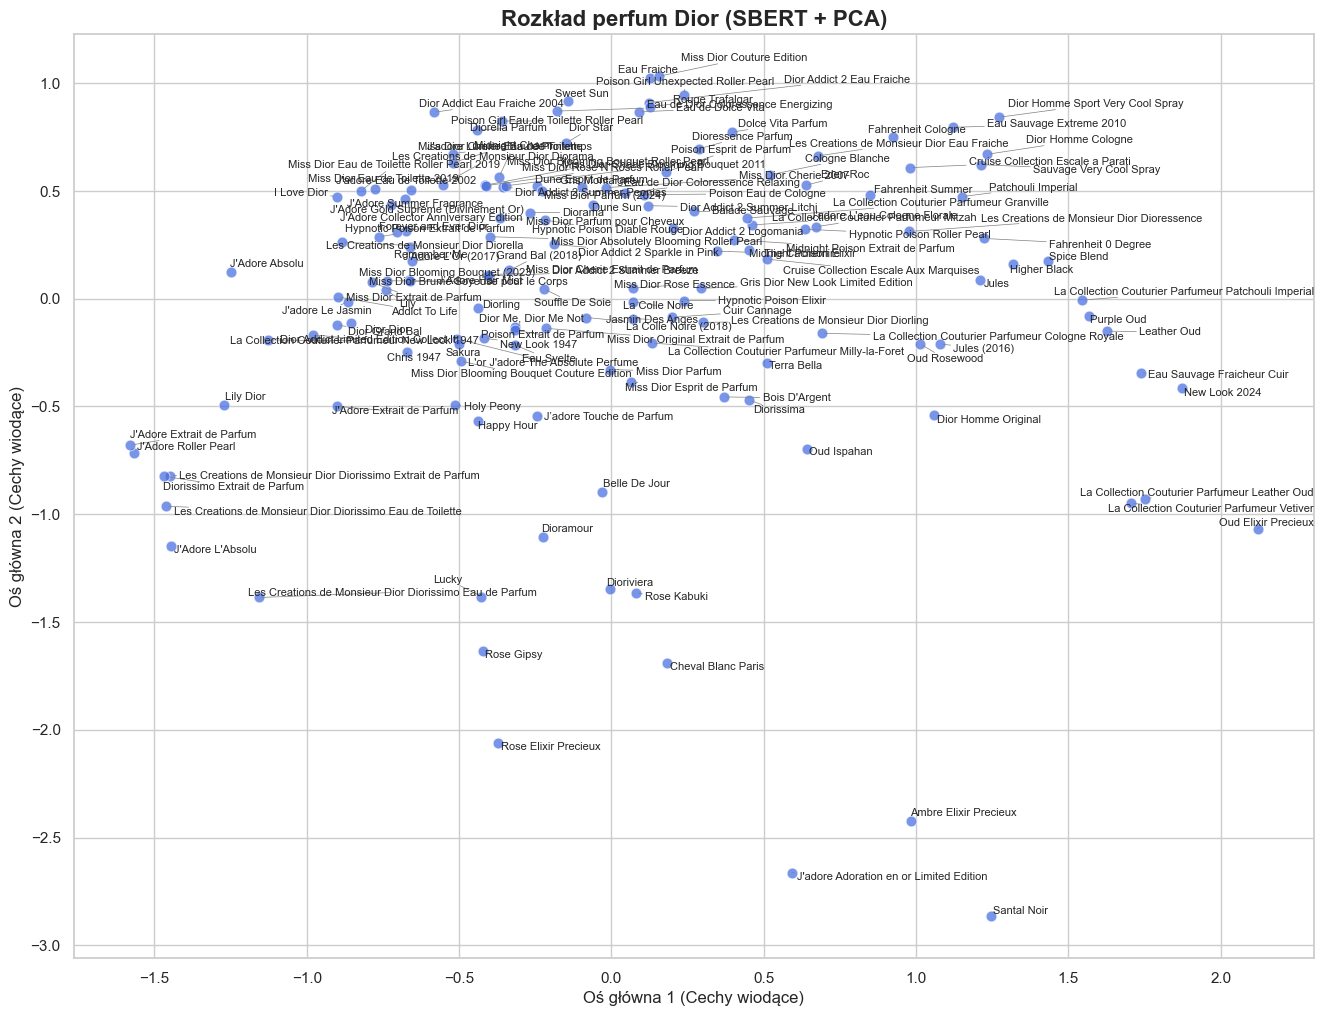

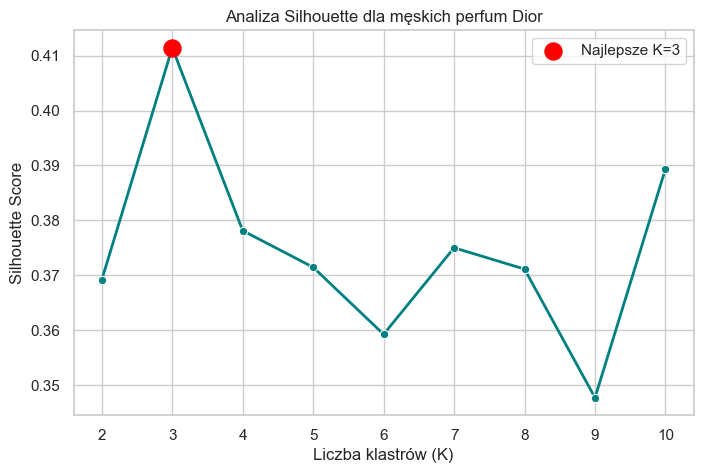


Najlepszy wynik = 3 podgrup (Silhouette Score: 0.4114)


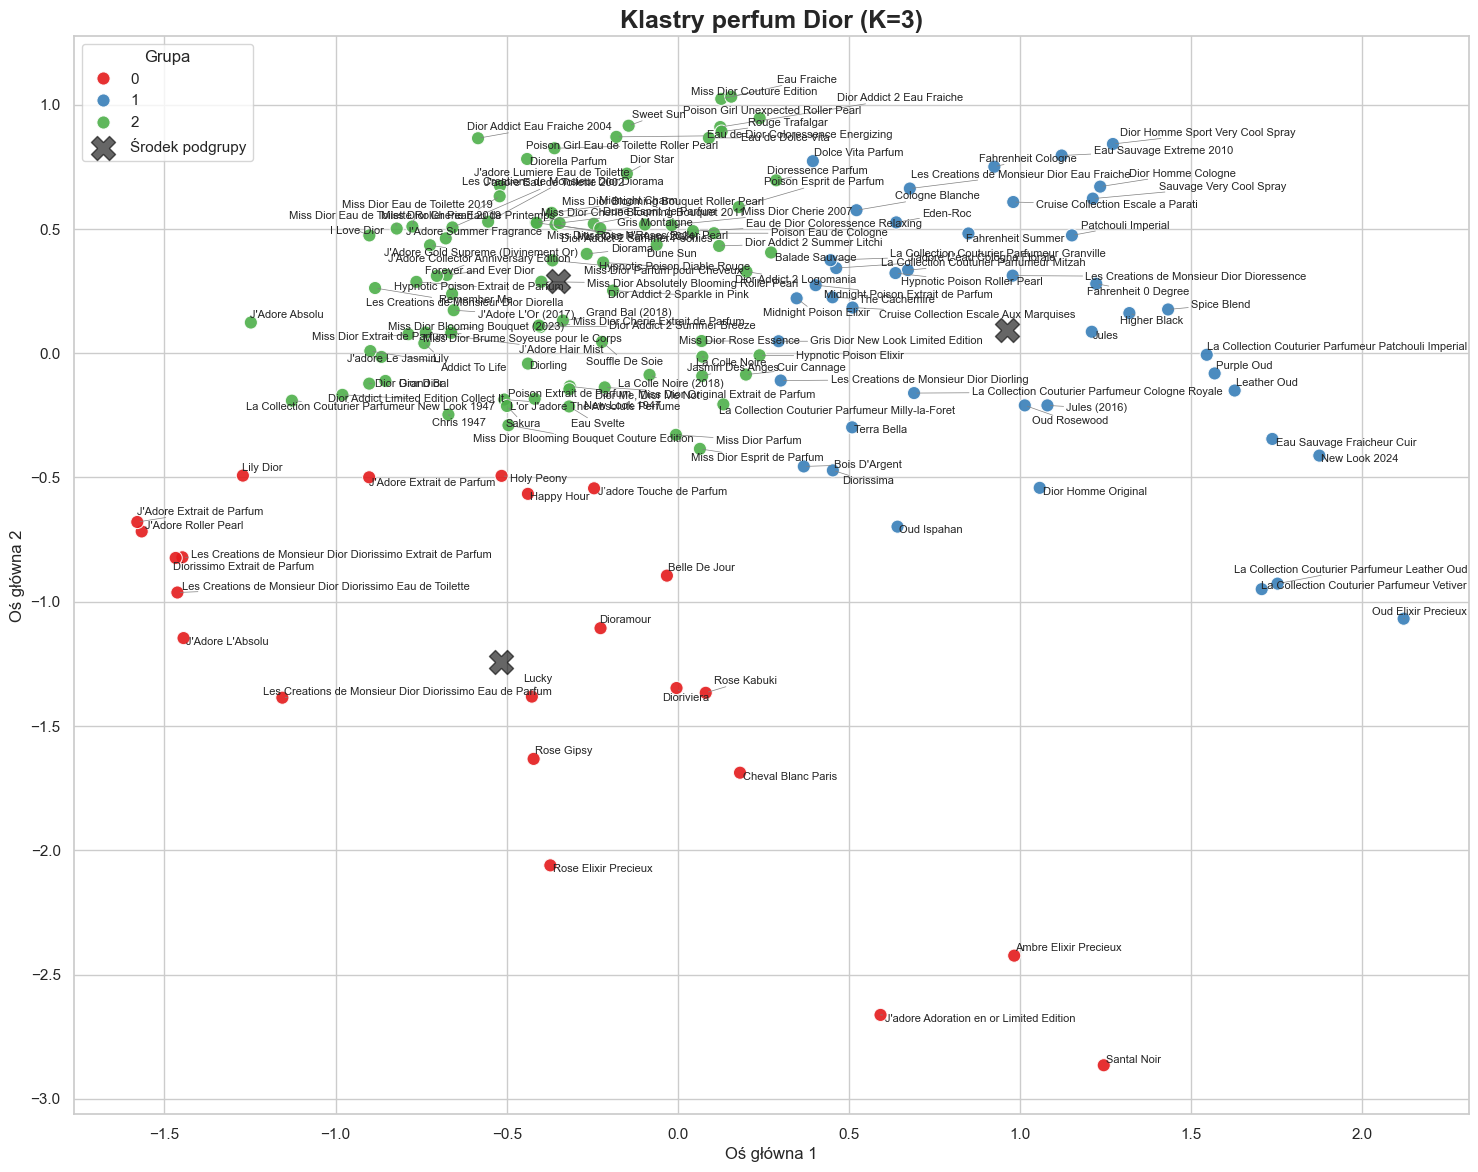

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

mask_brand = df_modeling['Brand'].str.contains('Dior', case=False, na=False)

df_sample = df_modeling[mask_brand].copy().reset_index(drop=True)

print(f"Znaleziono {len(df_sample)} perfum Dior w bazie.")

X_sample_embeddings = np.array(df_sample['Embeddings'].tolist())
pca_sample = PCA(n_components=2, random_state=42)
X_sample_pca = pca_sample.fit_transform(X_sample_embeddings)
df_sample['PCA_X'] = X_sample_pca[:, 0]
df_sample['PCA_Y'] = X_sample_pca[:, 1]

plt.figure(figsize=(16, 12)) 
sns.scatterplot(x=df_sample['PCA_X'], y=df_sample['PCA_Y'], s=60, color='royalblue', alpha=0.7)

from adjustText import adjust_text

texts = []
for i in range(len(df_sample)):
    texts.append(plt.text(df_sample['PCA_X'][i], df_sample['PCA_Y'][i], 
                          df_sample['Name'][i], fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title('Rozkład perfum Dior (SBERT + PCA)', fontsize=16, fontweight='bold')
plt.xlabel('Oś główna 1 (Cechy wiodące)')
plt.ylabel('Oś główna 2 (Cechy wiodące)')
plt.show()

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels_temp = kmeans_temp.fit_predict(df_sample[['PCA_X', 'PCA_Y']])
    score = silhouette_score(df_sample[['PCA_X', 'PCA_Y']], labels_temp)
    silhouette_scores.append(score)

best_k_idx = silhouette_scores.index(max(silhouette_scores))
best_k = k_values[best_k_idx]
best_score = silhouette_scores[best_k_idx]

plt.figure(figsize=(8, 5))
sns.lineplot(x=k_values, y=silhouette_scores, marker='o', color='teal', linewidth=2)
plt.scatter(best_k, best_score, color='red', s=150, zorder=5, label=f'Najlepsze K={best_k}')
plt.title('Analiza Silhouette dla męskich perfum Dior')
plt.xlabel('Liczba klastrów (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.show()

print(f"\nNajlepszy wynik = {best_k} podgrup (Silhouette Score: {best_score:.4f})")

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
df_sample['Cluster_ID'] = kmeans_final.fit_predict(df_sample[['PCA_X', 'PCA_Y']])

plt.figure(figsize=(18, 14))
sns.scatterplot(x=df_sample['PCA_X'], y=df_sample['PCA_Y'], 
                hue=df_sample['Cluster_ID'], palette='Set1', s=90, alpha=0.9)

from adjustText import adjust_text

texts = []
for i in range(len(df_sample)):
    texts.append(plt.text(df_sample['PCA_X'][i], df_sample['PCA_Y'][i], 
                          df_sample['Name'][i], fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

centroids = kmeans_final.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=300, marker='X', alpha=0.6, label='Środek podgrupy')

plt.title(f'Klastry perfum Dior (K={best_k})', fontsize=18, fontweight='bold')
plt.xlabel('Oś główna 1')
plt.ylabel('Oś główna 2')
plt.legend(title='Grupa')
plt.show()